### Test Resizing Images to 300 x 300

In [93]:
from pathlib import Path
from torchvision import io
from torchvision.transforms import v2

img_path = Path("../data/VOCtrainval-2007/JPEGImages/000005.jpg")

image = io.decode_image(img_path)
image_resized = v2.Resize((300, 300))(image)
image_resized.shape

torch.Size([3, 300, 300])

torch.Size([300, 300, 3])


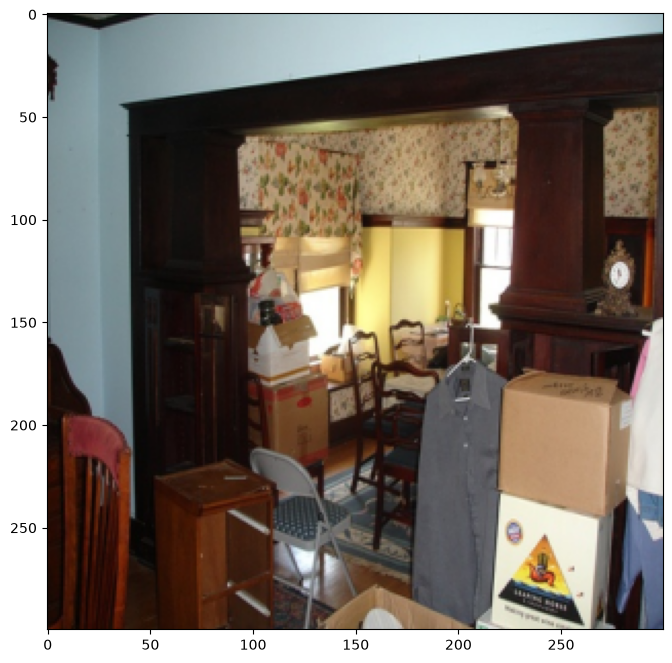

In [94]:
from matplotlib import pyplot as plt

fix, ax = plt.subplots(1, figsize=(8, 8))

image = image_resized.permute(1, 2, 0)
print(image.shape)

ax.imshow(image)

### Figure Out How to Iterate Through Images in Directory

In [102]:
import os 

img_dir = Path("../data/VOCtrainval-2007/JPEGImages")
img_list = os.listdir(img_dir) # Figured it out.
print(len(img_list), img_list[:5])

5011 ['000005.jpg', '000007.jpg', '000009.jpg', '000012.jpg', '000016.jpg']


### Figure Out How to Parse XML

In [103]:
annot_dir = Path("../data/VOCtrainval-2007/Annotations")
annot_list = os.listdir(annot_dir)

annot_1_path = os.path.join(annot_dir, annot_list[0])
annot_1_path

'..\\data\\VOCtrainval-2007\\Annotations\\000005.xml'

In [104]:
import pandas as pd

df = pd.read_xml(annot_1_path, parser="etree")
coord_df = pd.read_xml(annot_1_path, parser="etree", xpath=".//bndbox")

print(df)
print(coord_df)

     folder    filename              database      annotation   image  \
0   VOC2007         NaN                   NaN             NaN     NaN   
1       NaN  000005.jpg                   NaN             NaN     NaN   
2       NaN         NaN  The VOC2007 Database  PASCAL VOC2007  flickr   
3       NaN         NaN                   NaN             NaN     NaN   
4       NaN         NaN                   NaN             NaN     NaN   
5       NaN         NaN                   NaN             NaN     NaN   
6       NaN         NaN                   NaN             NaN     NaN   
7       NaN         NaN                   NaN             NaN     NaN   
8       NaN         NaN                   NaN             NaN     NaN   
9       NaN         NaN                   NaN             NaN     NaN   
10      NaN         NaN                   NaN             NaN     NaN   

                 flickrid   name  width  height  depth  segmented  \
0                     NaN    NaN    NaN     NaN    NaN

In [97]:
labels = {"filename": df["filename"][1]}

for i in range(0, len(coord_df)):
    row = coord_df.iloc[i]
    obj = {
        "class": df["name"][6+i], 
        "xmin": row["xmin"], 
        "ymin": row["ymin"], 
        "xmax": row["xmax"], 
        "ymax": row["ymax"]
    }
    labels[f"obj_{i+1}"] = obj

print(labels)

{'filename': '000005.jpg', 'obj_1': {'class': 'chair', 'xmin': np.int64(263), 'ymin': np.int64(211), 'xmax': np.int64(324), 'ymax': np.int64(339)}, 'obj_2': {'class': 'chair', 'xmin': np.int64(165), 'ymin': np.int64(264), 'xmax': np.int64(253), 'ymax': np.int64(372)}, 'obj_3': {'class': 'chair', 'xmin': np.int64(5), 'ymin': np.int64(244), 'xmax': np.int64(67), 'ymax': np.int64(374)}, 'obj_4': {'class': 'chair', 'xmin': np.int64(241), 'ymin': np.int64(194), 'xmax': np.int64(295), 'ymax': np.int64(299)}, 'obj_5': {'class': 'chair', 'xmin': np.int64(277), 'ymin': np.int64(186), 'xmax': np.int64(312), 'ymax': np.int64(220)}}


### Draw Bounding Boxes on Original Image

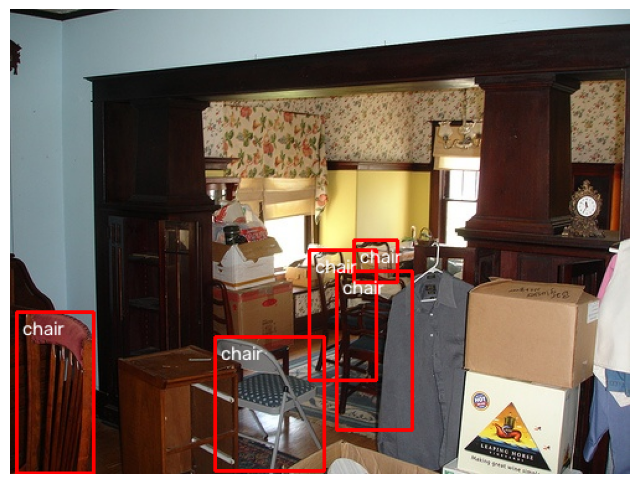

In [158]:
import bbox_visualizer as bbv
import numpy as np

directory = Path("../data/VOCtrainval-2007/JPEGImages")
img_list = os.listdir(directory) 

fig, ax = plt.subplots(1, figsize=(8, 8))

img_path = os.path.join(img_dir, img_list[0])
image = io.decode_image(img_path).permute(1, 2, 0).numpy()

annot_path = os.path.join(annot_dir, annot_list[0])  
df = pd.read_xml(annot_path, parser="etree")
coord_df = pd.read_xml(annot_path, parser="etree", xpath=".//bndbox")

class_labels, obj_coords = tuple(), []
for i in range(0, len(coord_df)):
    row = coord_df.iloc[i]
    class_labels += (df["name"][6+i],)
    obj_coords.append((row["xmin"], row["ymin"], row["xmax"], row["ymax"]))

image = bbv.draw_multiple_rectangles(image, obj_coords, bbox_color=(255, 0, 0), thickness=2)
image = bbv.add_multiple_labels(image, class_labels, obj_coords, size=0.5, thickness=1, 
                                text_color=(255, 255, 255), draw_bg=False, top=False)

ax.imshow(image)
ax.axis(False)

plt.show()

### Adjust Coordinates to Match 300 x 300 Image Dimensions

In [148]:
annot_path = os.path.join(annot_dir, annot_list[0])  
df = pd.read_xml(annot_path, parser="etree")
coord_df = pd.read_xml(annot_path, parser="etree", xpath=".//bndbox")

class_labels, obj_coords = tuple(), []
for i in range(0, len(coord_df)):
    width = df["width"][4]
    height = df["height"][4]
    w_ratio = 300 / width
    h_ratio = 300 / height
    row = coord_df.iloc[i]
    class_labels += (df["name"][6+i],)
    obj_coords.append((
        int(np.floor(row["xmin"]*w_ratio)),
        int(np.floor(row["ymin"]*h_ratio)), 
        int(np.floor(row["xmax"]*w_ratio)), 
        int(np.floor(row["ymax"]*h_ratio))))

print(class_labels, obj_coords)

('chair', 'chair', 'chair', 'chair', 'chair') [(157, 168, 194, 271), (99, 211, 151, 297), (3, 195, 40, 299), (144, 155, 177, 239), (166, 148, 187, 176)]


### Test Bounding Boxes

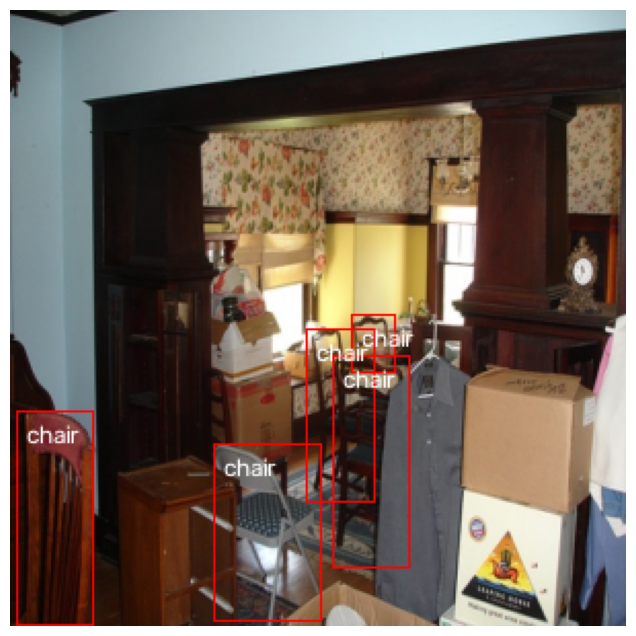

In [157]:
fig, ax = plt.subplots(1, figsize=(8, 8))

img_path = os.path.join(img_dir, img_list[0])
image = io.decode_image(img_path)
image = v2.Resize((300, 300))(image)
image = image.permute(1, 2, 0).numpy()

image = bbv.draw_multiple_rectangles(image, obj_coords, bbox_color=(255, 0, 0), thickness=1)
image = bbv.add_multiple_labels(image, class_labels, obj_coords, size=0.4, thickness=1, 
                                text_color=(255, 255, 255), draw_bg=False, top=False)

ax.imshow(image)
ax.axis(False)

plt.show()